# Notebook 3. Visualizations

Static plots plus interactive charts. Reads from db/projection.db, so notebooks 1 and 2 must have been run first.

Static plots are saved to plots/population and plots/labor_force.

1. Age pyramid for California 2023 vs 2058
2. National totals over time for observed and projected
3. Top and bottom states by 2058 growth
4. Labor force trajectories for benchmark states

Interactive Plotly charts render inside the notebook and respond to hover, pan, and zoom.

5. Interactive national choropleth for 2058 population
6. Interactive time series for any state
7. Interactive age pyramid

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'vscode'
%matplotlib inline

PROJECT_ROOT = Path.cwd().parent
DB_PATH = PROJECT_ROOT / 'db' / 'projection.db'
PLOTS_DIR = PROJECT_ROOT / 'plots'
(PLOTS_DIR / 'population').mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'labor_force').mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
conn = sqlite3.connect(DB_PATH)
states_df = pd.read_sql('SELECT state_code, state_name FROM states ORDER BY state_name', conn)

## 1. Age pyramid for California 2023 vs 2058

C:\Users\User\AppData\Local\Temp\ipykernel_29516\2805793072.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(t)):,}' for t in ticks])
C:\Users\User\AppData\Local\Temp\ipykernel_29516\2805793072.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(t)):,}' for t in ticks])


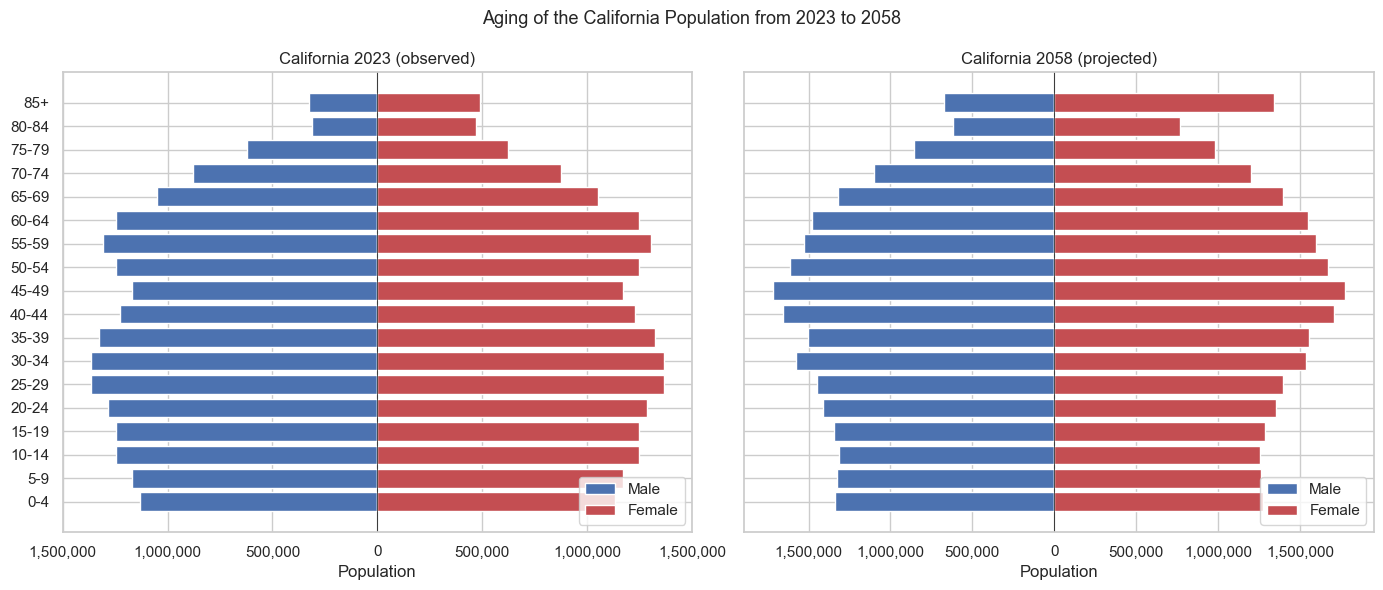

In [2]:
def pyramid_data(state_code, year, is_projection):
    return pd.read_sql("""
        SELECT ag.age_group, ag.sort_order, p.sex, SUM(p.population) AS population
        FROM population p JOIN age_groups ag ON ag.age_group = p.age_group
        WHERE p.state_code = ? AND p.year = ? AND p.is_projection = ?
        GROUP BY ag.age_group, ag.sort_order, p.sex
        ORDER BY ag.sort_order, p.sex
    """, conn, params=(state_code, year, is_projection))

def plot_pyramid(df, title, ax=None):
    pivot = df.pivot(index='age_group', columns='sex', values='population').reindex(
        df.sort_values('sort_order')['age_group'].unique()
    )
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    ax.barh(pivot.index, -pivot['m'], color='#4C72B0', label='Male')
    ax.barh(pivot.index,  pivot['f'], color='#C44E52', label='Female')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Population')
    ticks = ax.get_xticks()
    ax.set_xticklabels([f'{abs(int(t)):,}' for t in ticks])
    ax.legend(loc='lower right')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
plot_pyramid(pyramid_data('CA', 2023, 0), 'California 2023 (observed)', ax=ax1)
plot_pyramid(pyramid_data('CA', 2058, 1), 'California 2058 (projected)', ax=ax2)
fig.suptitle('Aging of the California Population from 2023 to 2058', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'population' / 'CA_pyramid_2023_vs_2058.png', dpi=120)
plt.show()

## 2. National totals over time

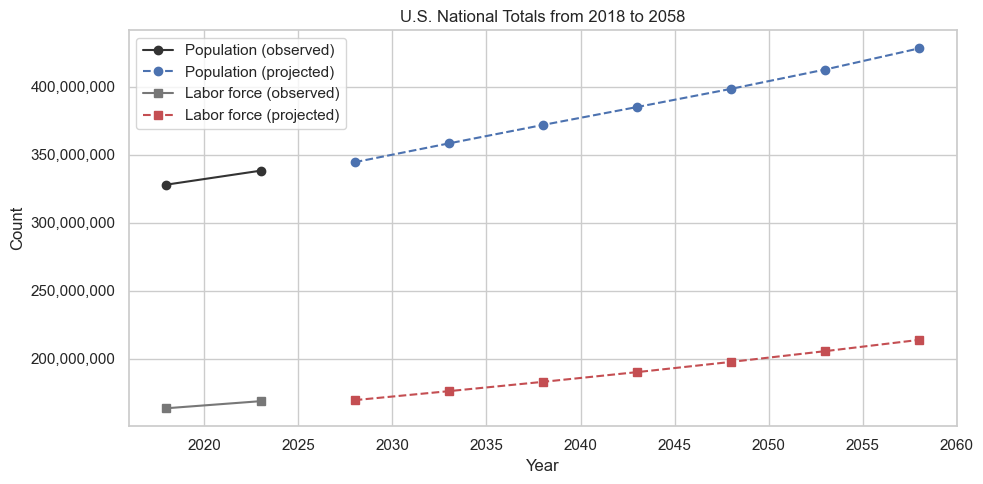

In [3]:
national = pd.read_sql("""
    SELECT year, is_projection,
           SUM(total_population)  AS total_population,
           SUM(total_labor_force) AS total_labor_force
    FROM v_state_year_totals
    GROUP BY year, is_projection
    ORDER BY year
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
obs = national[national['is_projection'] == 0]
proj = national[national['is_projection'] == 1]
ax.plot(obs['year'],  obs['total_population'],  'o-',  color='#333',    label='Population (observed)')
ax.plot(proj['year'], proj['total_population'], 'o--', color='#4C72B0', label='Population (projected)')
ax.plot(obs['year'],  obs['total_labor_force'],  's-',  color='#777',    label='Labor force (observed)')
ax.plot(proj['year'], proj['total_labor_force'], 's--', color='#C44E52', label='Labor force (projected)')
ax.set_title('U.S. National Totals from 2018 to 2058')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'population' / 'national_totals_2018_2058.png', dpi=120)
plt.show()

## 3. State growth ranking for top and bottom 10

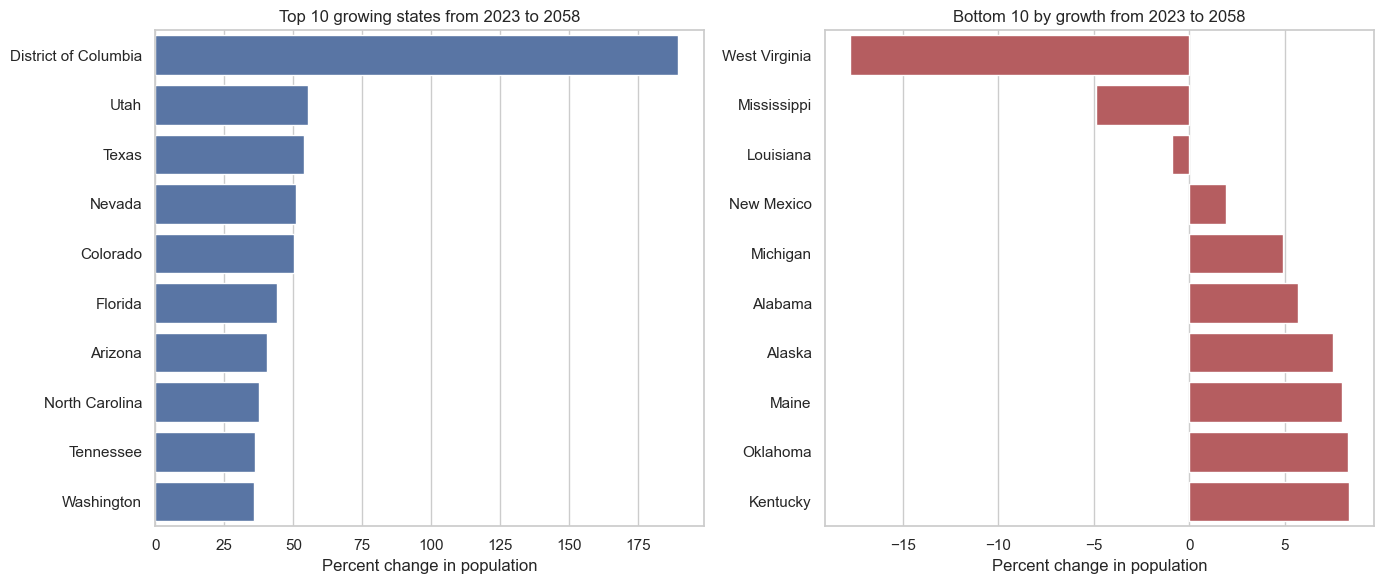

In [4]:
state_growth = pd.read_sql("""
    SELECT
        s.state_name,
        SUM(CASE WHEN p.year = 2023 AND p.is_projection = 0 THEN p.population ELSE 0 END) AS pop_2023,
        SUM(CASE WHEN p.year = 2058 AND p.is_projection = 1 THEN p.population ELSE 0 END) AS pop_2058
    FROM population p
    JOIN states s ON s.state_code = p.state_code
    GROUP BY p.state_code
""", conn)
state_growth['pct_change'] = 100 * (state_growth['pop_2058'] - state_growth['pop_2023']) / state_growth['pop_2023']
state_growth = state_growth.sort_values('pct_change', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top = state_growth.head(10)
bot = state_growth.tail(10).sort_values('pct_change')
sns.barplot(data=top, x='pct_change', y='state_name', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 10 growing states from 2023 to 2058')
axes[0].set_xlabel('Percent change in population')
axes[0].set_ylabel('')
sns.barplot(data=bot, x='pct_change', y='state_name', ax=axes[1], color='#C44E52')
axes[1].set_title('Bottom 10 by growth from 2023 to 2058')
axes[1].set_xlabel('Percent change in population')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'population' / 'state_growth_ranking.png', dpi=120)
plt.show()

## 4. Labor force trajectories for benchmark states

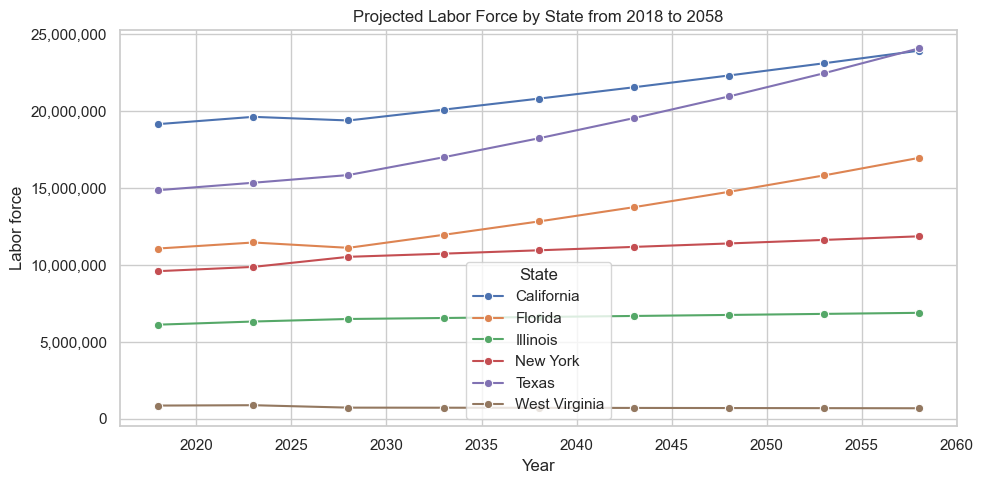

In [5]:
benchmark_states = ['CA', 'TX', 'FL', 'NY', 'IL', 'WV']
lf_traj = pd.read_sql(f"""
    SELECT state_name, year, total_labor_force
    FROM v_state_year_totals
    WHERE state_code IN ({','.join(['?']*len(benchmark_states))})
    ORDER BY state_name, year
""", conn, params=benchmark_states)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=lf_traj, x='year', y='total_labor_force', hue='state_name', marker='o', ax=ax)
ax.set_title('Projected Labor Force by State from 2018 to 2058')
ax.set_xlabel('Year')
ax.set_ylabel('Labor force')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='State')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'labor_force' / 'benchmark_states_trajectories.png', dpi=120)
plt.show()

## 5. Interactive national choropleth for 2058 population

Hover over any state for exact values. Pan and zoom also work.

In [6]:
map_data = pd.read_sql("""
    SELECT state_code, state_name, total_population, total_labor_force
    FROM v_state_year_totals
    WHERE year = 2058
""", conn)

fig_map = px.choropleth(
    map_data, locations='state_code', locationmode='USA-states', scope='usa',
    color='total_population', color_continuous_scale='Viridis',
    hover_name='state_name',
    labels={'total_population':'Population'},
    title='Projected Population by State in 2058',
)
fig_map.update_layout(margin=dict(l=0, r=0, t=40, b=0), height=500)
fig_map.show()

## 6. Interactive time series for a chosen state

Change STATE_CODE to any 2 letter state code and rerun the cell.

In [7]:
STATE_CODE = 'CA'

traj = pd.read_sql("""
    SELECT year, is_projection, total_population, total_labor_force
    FROM v_state_year_totals WHERE state_code = ? ORDER BY year
""", conn, params=(STATE_CODE,))
state_name = states_df.loc[states_df['state_code'] == STATE_CODE, 'state_name'].iloc[0]

fig = go.Figure()
for kind, mask, dash in [('Observed', traj['is_projection'] == 0, 'solid'),
                         ('Projected', traj['is_projection'] == 1, 'dash')]:
    sub = traj[mask]
    fig.add_trace(go.Scatter(x=sub['year'], y=sub['total_population'],
                             mode='lines+markers', name=f'Population ({kind})',
                             line=dict(dash=dash, color='#4C72B0')))
    fig.add_trace(go.Scatter(x=sub['year'], y=sub['total_labor_force'],
                             mode='lines+markers', name=f'Labor force ({kind})',
                             line=dict(dash=dash, color='#C44E52')))
fig.update_layout(title=f'{state_name} Population and Labor Force from 2018 to 2058',
                  xaxis_title='Year', yaxis_title='Count', height=450)
fig.show()

## 7. Interactive age pyramid

Plotly age pyramid for a chosen state and year. Change STATE_CODE and YEAR and rerun.

In [8]:
STATE_CODE = 'TX'
YEAR = 2058

df = pd.read_sql("""
    SELECT ag.age_group, ag.sort_order, p.sex, SUM(p.population) AS population
    FROM population p JOIN age_groups ag ON ag.age_group = p.age_group
    WHERE p.state_code = ? AND p.year = ?
    GROUP BY ag.age_group, ag.sort_order, p.sex
    ORDER BY ag.sort_order
""", conn, params=(STATE_CODE, YEAR))
pivot = df.pivot(index='age_group', columns='sex', values='population').reindex(
    df.sort_values('sort_order')['age_group'].unique()
).fillna(0)
state_name = states_df.loc[states_df['state_code'] == STATE_CODE, 'state_name'].iloc[0]

fig = go.Figure()
fig.add_trace(go.Bar(y=pivot.index, x=-pivot.get('m', 0), name='Male',
                     orientation='h', marker_color='#4C72B0'))
fig.add_trace(go.Bar(y=pivot.index, x= pivot.get('f', 0), name='Female',
                     orientation='h', marker_color='#C44E52'))
fig.update_layout(title=f'{state_name} Age Pyramid in {YEAR}',
                  barmode='relative', height=520,
                  xaxis_title='Population', yaxis_title='Age group')
fig.show()

In [9]:
conn.close()